#**Random Forest**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.tree import DecisionTreeClassifier


In [ ]:
file = pd.ExcelFile('glass.xlsx')
abc = pd.read_excel(file, 'Description')
df = pd.read_excel(file, 'glass')

In [ ]:
abc

,Prepare a model for glass classification using Random Forest
0,Data Description:
1,RI : refractive index
2,Na: Sodium (unit measurement: weight percent i...
3,Mg: Magnesium
4,AI: Aluminum
5,Si: Silicon
6,K:Potassium
7,Ca: Calcium
8,Ba: Barium
9,Fe: Iron


In [ ]:
print(df.head())

        RI     Na    Mg    Al     Si     K    Ca   Ba   Fe  Type
0  1.52101  13.64  4.49  1.10  71.78  0.06  8.75  0.0  0.0     1
1  1.51761  13.89  3.60  1.36  72.73  0.48  7.83  0.0  0.0     1
2  1.51618  13.53  3.55  1.54  72.99  0.39  7.78  0.0  0.0     1
3  1.51766  13.21  3.69  1.29  72.61  0.57  8.22  0.0  0.0     1
4  1.51742  13.27  3.62  1.24  73.08  0.55  8.07  0.0  0.0     1


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB
None


###Exploratory Data Analysis (EDA)


In [ ]:
print(df.describe())

               RI          Na          Mg          Al          Si           K  \
count  214.000000  214.000000  214.000000  214.000000  214.000000  214.000000   
mean     1.518365   13.407850    2.684533    1.444907   72.650935    0.497056   
std      0.003037    0.816604    1.442408    0.499270    0.774546    0.652192   
min      1.511150   10.730000    0.000000    0.290000   69.810000    0.000000   
25%      1.516522   12.907500    2.115000    1.190000   72.280000    0.122500   
50%      1.517680   13.300000    3.480000    1.360000   72.790000    0.555000   
75%      1.519157   13.825000    3.600000    1.630000   73.087500    0.610000   
max      1.533930   17.380000    4.490000    3.500000   75.410000    6.210000   

               Ca          Ba          Fe        Type  
count  214.000000  214.000000  214.000000  214.000000  
mean     8.956963    0.175047    0.057009    2.780374  
std      1.423153    0.497219    0.097439    2.103739  
min      5.430000    0.000000    0.000000    1

In [ ]:
df.isnull().any()

,0
RI,False
Na,False
Mg,False
Al,False
Si,False
K,False
Ca,False
Ba,False
Fe,False
Type,False


In [ ]:
# check for duplicate values
df.duplicated().any()

np.True_

In [ ]:
# remove duplicates
df.drop_duplicates(inplace=True)

In [ ]:
# after removing duplicate
df.duplicated().any()

np.False_

In [ ]:
y = df[['Type']]            #target
x = df.drop('Type', axis=1) #features

In [ ]:
x

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.00,0.0
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.00,0.0
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.00,0.0
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.00,0.0
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.00,0.0
...,...,...,...,...,...,...,...,...,...
209,1.51623,14.14,0.00,2.88,72.61,0.08,9.18,1.06,0.0
210,1.51685,14.92,0.00,1.99,73.06,0.00,8.40,1.59,0.0
211,1.52065,14.36,0.00,2.02,73.42,0.00,8.44,1.64,0.0
212,1.51651,14.38,0.00,1.94,73.61,0.00,8.48,1.57,0.0


###Data Visualization

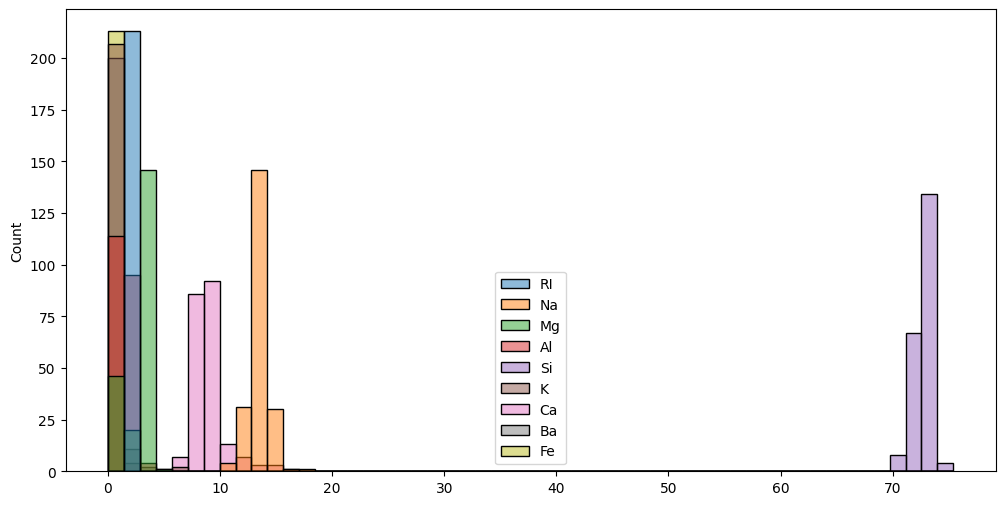

In [ ]:
# Histogram plot
plt.figure(figsize=(12,6))
sns.histplot(x, kde=False)
plt.show()

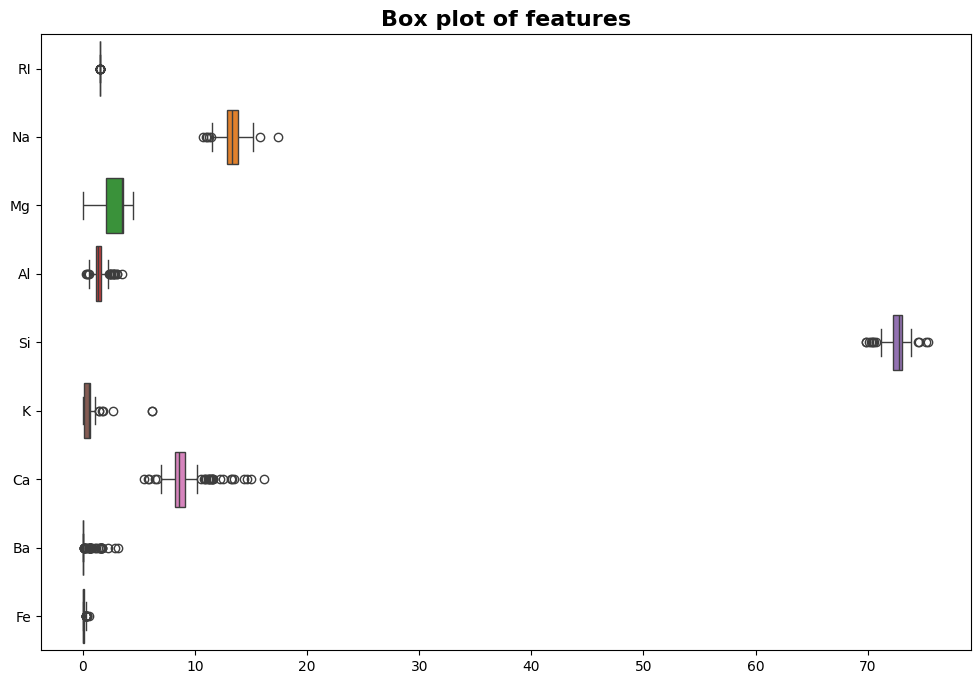

In [ ]:
# box plot of features
plt.figure(figsize=(12,8))
sns.boxplot(data=x, orient='h')
plt.title('Box plot of features',fontsize=16,weight='bold')
plt.show()

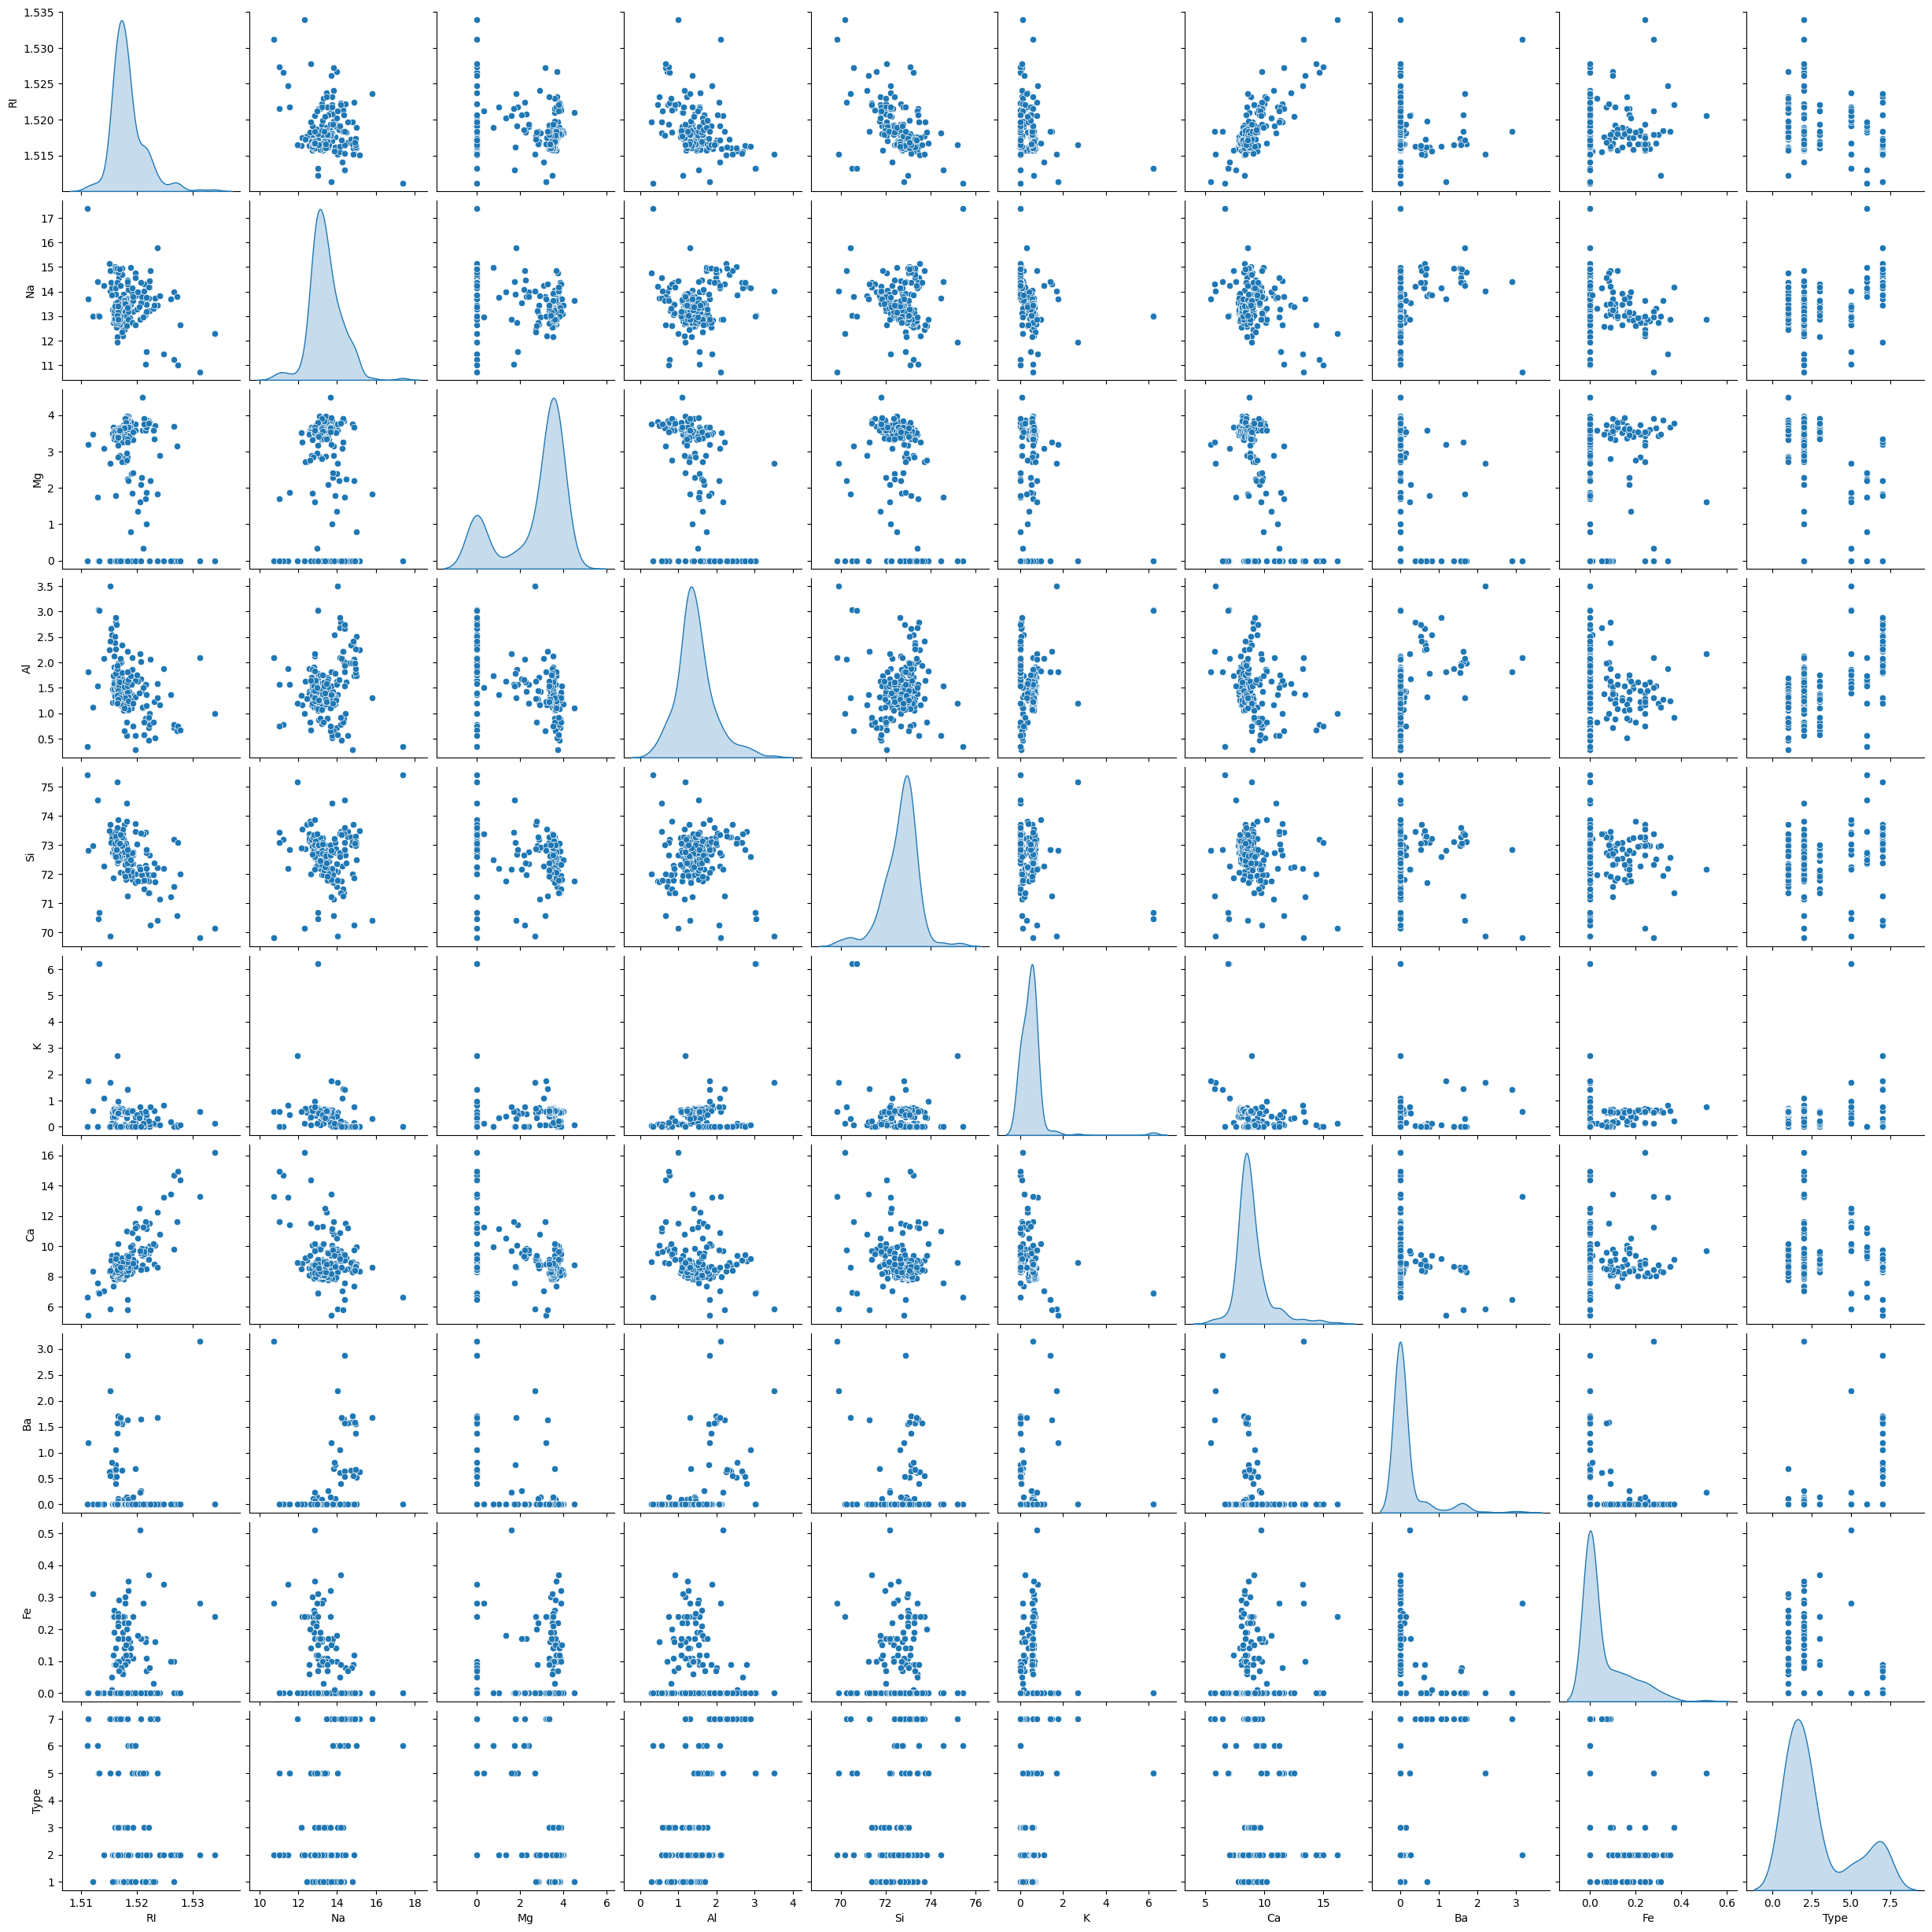

In [ ]:
sns.pairplot(df,diag_kind='kde')
plt.show()

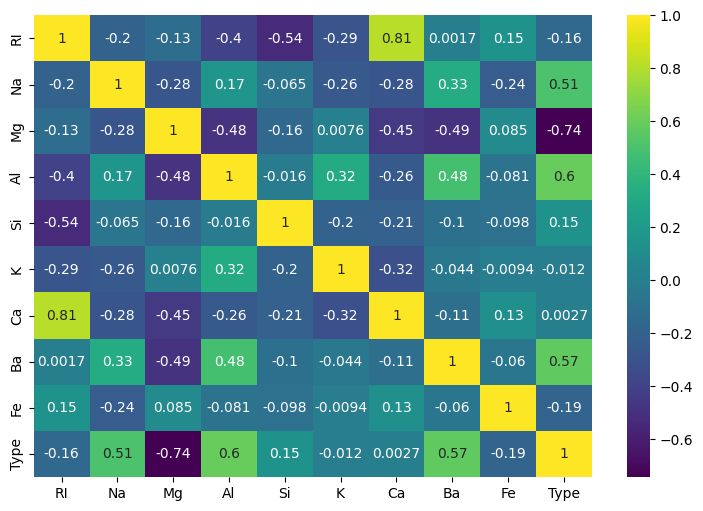

In [ ]:
# Correlation matrix
fig, ax = plt.subplots(figsize=(9,6))
sns.heatmap(df.corr(), annot=True, fmt='.2g', cmap="viridis")
plt.show()

In [ ]:
# Split into training and testing data
x_train,x_test,y_train,y_test= train_test_split(x,y,train_size=0.75,random_state=100)

In [ ]:
# Initiating Random Forest Classifier

rfc = RandomForestClassifier(n_estimators=50,bootstrap=True)
rfc.fit(x_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier(n_estimators=50)

In [ ]:
y_pred = rfc.predict(x_test)
y_pred

array([2, 1, 2, 7, 2, 1, 5, 2, 7, 1, 1, 1, 1, 3, 6, 1, 1, 2, 2, 2, 2, 7,
       7, 2, 2, 3, 2, 2, 1, 7, 2, 1, 7, 1, 2, 5, 2, 1, 6, 5, 1, 1, 1, 2,
       2, 1, 7, 1, 2, 7, 2, 2, 7, 5])

In [ ]:
# Accuracy score

accuracy_score(y_test, y_pred)

0.7592592592592593

In [ ]:
# Classification report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.71      1.00      0.83        12
           2       0.75      0.79      0.77        19
           3       0.50      0.25      0.33         4
           5       1.00      0.50      0.67         8
           6       1.00      0.67      0.80         3
           7       0.78      0.88      0.82         8

    accuracy                           0.76        54
   macro avg       0.79      0.68      0.70        54
weighted avg       0.78      0.76      0.74        54



In [ ]:
# Applying bagging method
bag_class= BaggingClassifier(DecisionTreeClassifier(),n_estimators=50,bootstrap=True)

bag_class.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_bagging.py:878: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=50)

In [ ]:
y_pred_bag=bag_class.predict(x_test)
y_pred_bag

array([2, 1, 5, 7, 2, 1, 5, 2, 7, 1, 1, 1, 1, 3, 1, 1, 1, 2, 2, 1, 5, 7,
       7, 1, 5, 3, 2, 2, 1, 7, 2, 1, 7, 1, 2, 5, 2, 1, 6, 5, 1, 1, 1, 2,
       2, 1, 7, 1, 2, 7, 2, 2, 7, 5])

In [ ]:
accuracy_score(y_test,y_pred_bag)

0.7222222222222222

In [ ]:
# Applying Adaboost method

ada_boost= AdaBoostClassifier(DecisionTreeClassifier(),n_estimators=50)
ada_boost.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


AdaBoostClassifier(estimator=DecisionTreeClassifier())

In [ ]:
y_pred_ada= ada_boost.predict(x_test)
y_pred_ada

array([2, 1, 5, 1, 2, 1, 5, 2, 7, 3, 1, 1, 3, 3, 1, 1, 1, 2, 2, 2, 5, 7,
       1, 1, 5, 3, 2, 2, 2, 1, 2, 1, 7, 1, 2, 5, 2, 1, 6, 5, 2, 1, 2, 2,
       1, 1, 7, 1, 2, 1, 1, 1, 7, 5])

In [ ]:
accuracy_score(y_test,y_pred_ada)

0.6296296296296297

In [ ]:
# Applying gradient boost method
grad_boost= GradientBoostingClassifier(n_estimators=50, learning_rate=0.3,max_depth=2)
grad_boost.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


GradientBoostingClassifier(learning_rate=0.3, max_depth=2, n_estimators=50)

In [ ]:
y_pred_grad= grad_boost.predict(x_test)

In [ ]:
accuracy_score(y_test,y_pred_grad)

0.7037037037037037

In [ ]:
# Evaluate the model performance using the obtained metrics

# Accuracy

acc=accuracy_score(y_test, y_pred)
print('Random forest  :', acc)

bagg = accuracy_score(y_test,y_pred_bag)
print('Bagging method :', bagg)

ada = accuracy_score(y_test,y_pred_ada)
print('ada boosting method :', ada)

grad = accuracy_score(y_test,y_pred_grad)
print('grad boosting method :', grad)


Random forest  : 0.7592592592592593
Bagging method : 0.7222222222222222
ada boosting method : 0.6296296296296297
grad boosting method : 0.7037037037037037


Accuracy heirarchy as follows:

Random Forest classifier  **<**  Bagging method  **<** Gradient boosting method **<** Adaboosting method

**1. Explain Bagging and Boosting methods. How is it different from each other.**

- Bagging trains multiple models in parallel on different random subsets of the training data.

-  Boosting trains models sequentially, where each new model focuses on correcting the errors of the previous one.

 Bagging
  - Parallel (independent models)
  - Reduces variance (stability)
  - Equal weight for all samples
  - Less prone to overfitting
   
    - ex:Random Forest
  
  Boosting
  - Sequential (each model depends on previous)
  - Reduces bias (accuracy)
  - Misclassified samples get higher weight
  - Can overfit if not regularize
    - ex: AdaBoost, Gradient Boosting

2. Explain how to handle imbalance in the data.

- Class imbalance occurs when some classes have far fewer samples than others, leading to biased predictions.
- Resampling (oversampling/undersampling) changes the dataset to balance classes.
- Class weights adjust the learning algorithm to emphasize minority classes.
- Balanced metrics ensure fair evaluation beyond simple accuracy.